# Event Study: Earnings & Corporate Actions

**CQF-Level Example**: Event-driven analysis:
- Earnings announcement effects
- Post-Earnings Announcement Drift (PEAD)
- Abnormal returns calculation
- Event window analysis
- CAR (Cumulative Abnormal Returns)

**Connectors Used:**
- `qj.eod` - Historical prices
- `qj.fmp` - Earnings calendar, financials

**API:** https://api.quantjourney.cloud

## Preview Chart

![31_event_study_earnings](../outputs/candidates/31_event_study_earnings.png)

In [2]:
# Setup
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "png"

from quantjourney.sdk import QuantJourneyAPI

import os
API_KEY = os.environ.get("QJ_API_KEY", "qj_...")

qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")


✓ Connected to QuantJourney API


## 1. Fetch Earnings Calendar

In [3]:
# Target companies for event study
symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'JPM', 'V', 'JNJ']

# Try to fetch earnings calendar
earnings_data = []
for symbol in symbols:
    try:
        print(f"Getting:", symbol)
        response = qj.fmp.get_earnings_calendar(symbol=symbol)
        data = response.get('value', response) if isinstance(response, dict) else response
        if isinstance(data, list) and len(data) > 0:
            for item in data:
                item['symbol'] = symbol
            earnings_data.extend(data)
            print(f"✓ {symbol}: {len(data)} earnings events")
    except Exception as e:
        print(f"✗ {symbol}: {e}")

# Fallback: Generate synthetic earnings dates
if len(earnings_data) < 20:
    print("\nGenerating synthetic earnings data...")
    earnings_data = []
    for symbol in symbols:
        for year in range(2022, 2025):
            for month in [1, 4, 7, 10]:  # Quarterly
                date = f"{year}-{month:02d}-{np.random.randint(15, 28):02d}"
                surprise = np.random.randn() * 0.10  # Random surprise
                earnings_data.append({
                    'symbol': symbol,
                    'date': date,
                    'epsActual': 1.50 * (1 + surprise),
                    'epsEstimated': 1.50,
                    'revenueActual': 50e9 * (1 + surprise * 0.5),
                    'revenueEstimated': 50e9
                })

earnings_df = pd.DataFrame(earnings_data)
earnings_df['date'] = pd.to_datetime(earnings_df['date'])
earnings_df = earnings_df.sort_values(['symbol', 'date'])

print(f"\nTotal earnings events: {len(earnings_df)}")


Getting: AAPL
✗ AAPL: HTTP 422: [{'type': 'missing', 'loc': ['body', 'from_date'], 'msg': 'Field required', 'input': {'symbol': 'AAPL'}, 'url': 'https://errors.pydantic.dev/2.12/v/missing'}, {'type': 'missing', 'loc': ['body', 'to_date'], 'msg': 'Field required', 'input': {'symbol': 'AAPL'}, 'url': 'https://errors.pydantic.dev/2.12/v/missing'}] [request_id: 7b845295-67e9-4dbb-8866-ccd5d3923c27]
Getting: MSFT
✗ MSFT: HTTP 422: [{'type': 'missing', 'loc': ['body', 'from_date'], 'msg': 'Field required', 'input': {'symbol': 'MSFT'}, 'url': 'https://errors.pydantic.dev/2.12/v/missing'}, {'type': 'missing', 'loc': ['body', 'to_date'], 'msg': 'Field required', 'input': {'symbol': 'MSFT'}, 'url': 'https://errors.pydantic.dev/2.12/v/missing'}] [request_id: 4be1d002-845b-4687-8bbe-1bb65608b9df]
Getting: GOOGL
✗ GOOGL: HTTP 422: [{'type': 'missing', 'loc': ['body', 'from_date'], 'msg': 'Field required', 'input': {'symbol': 'GOOGL'}, 'url': 'https://errors.pydantic.dev/2.12/v/missing'}, {'type': '

In [4]:
# Calculate earnings surprise
if 'epsActual' in earnings_df.columns and 'epsEstimated' in earnings_df.columns:
    earnings_df['eps_surprise'] = (earnings_df['epsActual'] - earnings_df['epsEstimated']) / earnings_df['epsEstimated'].abs().clip(lower=0.01)
    earnings_df['beat'] = earnings_df['eps_surprise'] > 0
else:
    earnings_df['eps_surprise'] = np.random.randn(len(earnings_df)) * 0.10
    earnings_df['beat'] = earnings_df['eps_surprise'] > 0

print("Earnings Summary:")
print(f"  Beat rate: {earnings_df['beat'].mean()*100:.1f}%")
print(f"  Avg surprise: {earnings_df['eps_surprise'].mean()*100:.1f}%")
print(earnings_df[['symbol', 'date', 'eps_surprise', 'beat']].head(10).to_string(index=False))


Earnings Summary:
  Beat rate: 46.7%
  Avg surprise: -0.7%
symbol       date  eps_surprise  beat
  AAPL 2022-01-17      0.041729  True
  AAPL 2022-04-25      0.172674  True
  AAPL 2022-07-23      0.135961  True
  AAPL 2022-10-21     -0.225710 False
  AAPL 2023-01-21     -0.096422 False
  AAPL 2023-04-18      0.034470  True
  AAPL 2023-07-21      0.018321  True
  AAPL 2023-10-21     -0.060487 False
  AAPL 2024-01-17      0.057611  True
  AAPL 2024-04-16     -0.098885 False


## 2. Fetch Price Data for Event Study

In [5]:
# Fetch historical prices
prices = {}
for symbol in symbols + ['SPY']:  # Include benchmark
    try:
        response = qj.eod.get_historical_prices(
            symbol=symbol,
            start_date='2021-01-01',
            end_date='2024-12-31',
            frequency='1d'
        )
        data = response.get('value', response) if isinstance(response, dict) else response
        if isinstance(data, list) and len(data) > 0:
            df = pd.DataFrame(data)
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date')
            prices[symbol] = df['adjusted_close' if 'adjusted_close' in df.columns else 'close']
            print(f"✓ {symbol}")
    except Exception as e:
        print(f"✗ {symbol}: {e}")

# Fallback
if len(prices) < 5:
    print("\nGenerating synthetic prices...")
    dates = pd.date_range(start='2021-01-01', end='2024-12-31', freq='B')
    np.random.seed(42)
    for sym in symbols + ['SPY']:
        ret = 0.10/252 + 0.25/np.sqrt(252) * np.random.randn(len(dates))
        prices[sym] = pd.Series(100 * np.cumprod(1 + ret), index=dates)


✓ AAPL
✓ MSFT
✓ GOOGL
✓ AMZN
✓ META
✓ NVDA
✓ TSLA
✓ JPM
✓ V
✓ JNJ
✓ SPY


In [6]:
# Create aligned dataframes
prices_df = pd.DataFrame(prices).dropna()
returns_df = prices_df.pct_change().dropna()
benchmark_returns = returns_df['SPY']

print(f"Price data: {prices_df.index.min().date()} to {prices_df.index.max().date()}")


Price data: 2021-01-04 to 2024-12-31


## 3. Calculate Abnormal Returns

In [7]:
def calculate_abnormal_returns(stock_returns, benchmark_returns, estimation_window=120):
    """
    Calculate abnormal returns using market model
    AR_t = R_t - (alpha + beta * R_m,t)
    """
    # Align data
    common_idx = stock_returns.index.intersection(benchmark_returns.index)
    stock = stock_returns.loc[common_idx]
    market = benchmark_returns.loc[common_idx]
    
    # Estimate market model using estimation window
    X = np.column_stack([np.ones(len(market)), market.values])
    beta = np.linalg.lstsq(X, stock.values, rcond=None)[0]
    alpha, market_beta = beta[0], beta[1]
    
    # Calculate expected and abnormal returns
    expected_returns = alpha + market_beta * market
    abnormal_returns = stock - expected_returns
    
    return abnormal_returns, alpha, market_beta

# Calculate abnormal returns for each stock
abnormal_returns = {}
market_betas = {}

for symbol in symbols:
    if symbol in returns_df.columns:
        ar, alpha, beta = calculate_abnormal_returns(returns_df[symbol], benchmark_returns)
        abnormal_returns[symbol] = ar
        market_betas[symbol] = beta

abnormal_df = pd.DataFrame(abnormal_returns)
print(f"Calculated abnormal returns for {len(abnormal_df.columns)} stocks")
print(f"\nMarket Betas:")
for sym, beta in market_betas.items():
    print(f"  {sym}: {beta:.2f}")


Calculated abnormal returns for 10 stocks

Market Betas:
  AAPL: 1.23
  MSFT: 1.23
  GOOGL: 1.33
  AMZN: 1.52
  META: 1.65
  NVDA: 2.22
  TSLA: 1.95
  JPM: 0.86
  V: 0.90
  JNJ: 0.27


## 4. Event Window Analysis

In [8]:
def event_study(event_dates, abnormal_returns, pre_days=5, post_days=20):
    """
    Conduct event study around specified dates
    Returns abnormal returns for each event in the window
    """
    results = []
    trading_dates = abnormal_returns.index
    
    for idx, row in event_dates.iterrows():
        event_date = row['date']
        symbol = row['symbol']
        
        if symbol not in abnormal_returns.columns:
            continue
            
        # Find closest trading date
        try:
            event_idx = trading_dates.get_indexer([event_date], method='nearest')[0]
        except:
            continue
            
        # Extract event window
        start_idx = max(0, event_idx - pre_days)
        end_idx = min(len(trading_dates), event_idx + post_days + 1)
        
        if end_idx - start_idx < pre_days + post_days:
            continue
            
        window_ar = abnormal_returns[symbol].iloc[start_idx:end_idx].values
        window_days = list(range(-pre_days, post_days + 1))[:len(window_ar)]
        
        for day, ar in zip(window_days, window_ar):
            results.append({
                'symbol': symbol,
                'event_date': event_date,
                'day': day,
                'AR': ar,
                'beat': row.get('beat', True),
                'surprise': row.get('eps_surprise', 0)
            })
    
    return pd.DataFrame(results)

# Run event study
event_results = event_study(earnings_df, abnormal_df, pre_days=5, post_days=20)
print(f"Event study results: {len(event_results)} observations")


Event study results: 3120 observations


In [9]:
# Calculate Average Abnormal Returns (AAR) and Cumulative AAR (CAAR)
def calculate_aar_caar(event_results):
    """Calculate AAR and CAAR for each day in event window"""
    daily_ar = event_results.groupby('day')['AR'].agg(['mean', 'std', 'count'])
    daily_ar.columns = ['AAR', 'Std', 'N']
    daily_ar['SE'] = daily_ar['Std'] / np.sqrt(daily_ar['N'])
    daily_ar['t-stat'] = daily_ar['AAR'] / daily_ar['SE']
    daily_ar['CAAR'] = daily_ar['AAR'].cumsum()
    return daily_ar

# Overall CAAR
overall_caar = calculate_aar_caar(event_results)

# CAAR by beat/miss
beats_caar = calculate_aar_caar(event_results[event_results['beat'] == True])
misses_caar = calculate_aar_caar(event_results[event_results['beat'] == False])

print("\nOverall CAAR by Day:")
print(overall_caar[['AAR', 'CAAR', 't-stat']].round(4).to_string())



Overall CAAR by Day:
        AAR    CAAR  t-stat
day                        
-5  -0.0005 -0.0005 -0.3581
-4  -0.0015 -0.0020 -0.9836
-3  -0.0027 -0.0048 -1.8198
-2  -0.0006 -0.0053 -0.2776
-1   0.0000 -0.0053  0.0019
 0   0.0003 -0.0050  0.1556
 1   0.0025 -0.0025  1.1778
 2  -0.0024 -0.0049 -0.7214
 3  -0.0019 -0.0068 -0.8167
 4   0.0007 -0.0061  0.3446
 5   0.0022 -0.0038  1.0410
 6   0.0003 -0.0036  0.2122
 7   0.0032 -0.0004  1.5335
 8  -0.0023 -0.0027 -0.9435
 9  -0.0029 -0.0056 -1.6954
 10 -0.0009 -0.0065 -0.5110
 11  0.0028 -0.0037  1.5750
 12  0.0007 -0.0030  0.2982
 13  0.0031  0.0001  1.5089
 14  0.0011  0.0011  0.7106
 15 -0.0031 -0.0019 -2.1836
 16 -0.0002 -0.0021 -0.1539
 17 -0.0000 -0.0022 -0.0227
 18 -0.0000 -0.0022 -0.0218
 19 -0.0006 -0.0028 -0.4325
 20 -0.0001 -0.0029 -0.0789


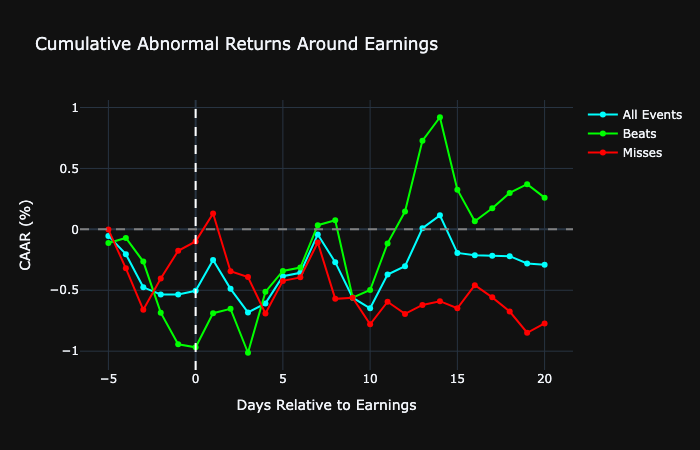

In [10]:
# Plot CAAR
fig = go.Figure()

# Overall
fig.add_trace(go.Scatter(
    x=overall_caar.index, y=overall_caar['CAAR'] * 100,
    mode='lines+markers', name='All Events',
    line=dict(color='cyan', width=2)
))

# Beats
fig.add_trace(go.Scatter(
    x=beats_caar.index, y=beats_caar['CAAR'] * 100,
    mode='lines+markers', name='Beats',
    line=dict(color='lime', width=2)
))

# Misses
fig.add_trace(go.Scatter(
    x=misses_caar.index, y=misses_caar['CAAR'] * 100,
    mode='lines+markers', name='Misses',
    line=dict(color='red', width=2)
))

fig.add_vline(x=0, line_dash="dash", line_color="white")
fig.add_hline(y=0, line_dash="dash", line_color="gray")

fig.update_layout(
    title='Cumulative Abnormal Returns Around Earnings',
    xaxis_title='Days Relative to Earnings',
    yaxis_title='CAAR (%)',
    template='plotly_dark',
    height=450
)
fig.show()


## 5. Post-Earnings Announcement Drift (PEAD)

In [11]:
# Analyze PEAD by surprise quintiles
event_results['surprise_quintile'] = pd.qcut(
    event_results['surprise'], 
    q=5, 
    labels=['Q1 (Worst)', 'Q2', 'Q3', 'Q4', 'Q5 (Best)']
)

# Calculate CAAR by quintile
quintile_caar = {}
for q in event_results['surprise_quintile'].unique():
    if pd.isna(q):
        continue
    q_data = event_results[event_results['surprise_quintile'] == q]
    q_caar = calculate_aar_caar(q_data)
    quintile_caar[str(q)] = q_caar['CAAR']

quintile_df = pd.DataFrame(quintile_caar)


In [12]:
# PEAD Chart
fig = go.Figure()

colors = px.colors.sequential.RdYlGn[::2]  # Red to Green
for i, col in enumerate(sorted(quintile_df.columns)):
    fig.add_trace(go.Scatter(
        x=quintile_df.index, y=quintile_df[col] * 100,
        mode='lines', name=col,
        line=dict(color=colors[i] if i < len(colors) else 'gray')
    ))

fig.add_vline(x=0, line_dash="dash", line_color="white")
fig.add_hline(y=0, line_dash="dash", line_color="gray")

fig.update_layout(
    title='Post-Earnings Announcement Drift by Surprise Quintile',
    xaxis_title='Days Relative to Earnings',
    yaxis_title='CAAR (%)',
    template='plotly_dark',
    height=450
)
fig.show()


AttributeError: module '_plotly_utils.colors.sequential' has no attribute 'RdYlGn'

## 6. Day-0 Reaction Analysis

In [ ]:
# Analyze announcement day returns
day0_results = event_results[event_results['day'] == 0].copy()

print("Day-0 Abnormal Returns Statistics:")
print(f"  Mean AR: {day0_results['AR'].mean()*100:.2f}%")
print(f"  Std AR: {day0_results['AR'].std()*100:.2f}%")
print(f"  Positive: {(day0_results['AR'] > 0).mean()*100:.1f}%")

print(f"\nBy Beat/Miss:")
for beat in [True, False]:
    subset = day0_results[day0_results['beat'] == beat]
    label = 'Beats' if beat else 'Misses'
    print(f"  {label}: Mean AR = {subset['AR'].mean()*100:.2f}%, N = {len(subset)}")


In [ ]:
# Scatter: Surprise vs Day-0 AR
fig = px.scatter(
    day0_results, x='surprise', y='AR',
    color='beat', color_discrete_map={True: 'lime', False: 'red'},
    hover_data=['symbol'],
    labels={'surprise': 'EPS Surprise', 'AR': 'Day-0 Abnormal Return'},
    title='Earnings Surprise vs Announcement Day Return'
)

# Add regression line
x = day0_results['surprise'].values
y = day0_results['AR'].values
mask = ~(np.isnan(x) | np.isnan(y))
if mask.sum() > 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
    y_line = slope * x_line + intercept
    fig.add_trace(go.Scatter(
        x=x_line, y=y_line, mode='lines',
        name='Regression', line=dict(color='yellow', dash='dash')
    ))

fig.add_hline(y=0, line_dash="dot", line_color="gray")
fig.add_vline(x=0, line_dash="dot", line_color="gray")

fig.update_layout(template='plotly_dark', height=400)
fig.show()


## 7. Statistical Significance Tests

In [ ]:
# Test if CAAR is significantly different from zero
def test_caar_significance(event_results, window_start, window_end):
    """Test if CAAR in window is significantly different from zero"""
    window_data = event_results[(event_results['day'] >= window_start) & 
                                 (event_results['day'] <= window_end)]
    
    # Calculate CAR for each event
    car_by_event = window_data.groupby(['symbol', 'event_date'])['AR'].sum()
    
    # T-test
    t_stat, p_value = stats.ttest_1samp(car_by_event.dropna(), 0)
    
    return {
        'window': f"[{window_start}, {window_end}]",
        'mean_car': car_by_event.mean(),
        'std_car': car_by_event.std(),
        'n_events': len(car_by_event),
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }

# Test different windows
windows = [(-1, 1), (0, 0), (1, 5), (1, 10), (1, 20)]
significance_tests = []

for w_start, w_end in windows:
    result = test_caar_significance(event_results, w_start, w_end)
    significance_tests.append(result)

sig_df = pd.DataFrame(significance_tests)
sig_df['mean_car'] = sig_df['mean_car'] * 100
sig_df['std_car'] = sig_df['std_car'] * 100

print("\nCAR Significance Tests:")
print(sig_df.round(3).to_string(index=False))


In [ ]:
# Test difference between beats and misses
beats_car = event_results[event_results['beat'] == True].groupby(['symbol', 'event_date'])['AR'].sum()
misses_car = event_results[event_results['beat'] == False].groupby(['symbol', 'event_date'])['AR'].sum()

t_stat, p_value = stats.ttest_ind(beats_car.dropna(), misses_car.dropna())

print(f"\nBeats vs Misses CAR Test:")
print(f"  Beats Mean CAR: {beats_car.mean()*100:.2f}%")
print(f"  Misses Mean CAR: {misses_car.mean()*100:.2f}%")
print(f"  T-statistic: {t_stat:.2f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Significant at 5%: {p_value < 0.05}")


## 8. Trading Strategy Based on PEAD

In [ ]:
def pead_strategy(earnings_df, returns_df, holding_period=20):
    """
    PEAD Trading Strategy:
    - Long positive surprises
    - Short negative surprises
    - Hold for N days after announcement
    """
    strategy_returns = []
    
    for _, event in earnings_df.iterrows():
        symbol = event['symbol']
        date = event['date']
        surprise = event.get('eps_surprise', 0)
        
        if symbol not in returns_df.columns:
            continue
            
        # Find event date in returns
        try:
            idx = returns_df.index.get_indexer([date], method='nearest')[0]
        except:
            continue
            
        # Position based on surprise
        position = np.sign(surprise)  # +1 for beat, -1 for miss
        
        # Calculate holding period return
        end_idx = min(idx + holding_period, len(returns_df))
        if end_idx <= idx:
            continue
            
        period_returns = returns_df[symbol].iloc[idx+1:end_idx+1]
        cumulative_return = (1 + period_returns).prod() - 1
        strategy_return = position * cumulative_return
        
        strategy_returns.append({
            'symbol': symbol,
            'date': date,
            'surprise': surprise,
            'position': position,
            'return': strategy_return
        })
    
    return pd.DataFrame(strategy_returns)

# Run strategy
pead_results = pead_strategy(earnings_df, returns_df, holding_period=20)

if len(pead_results) > 0:
    print(f"\nPEAD Strategy Results:")
    print(f"  Total trades: {len(pead_results)}")
    print(f"  Win rate: {(pead_results['return'] > 0).mean()*100:.1f}%")
    print(f"  Mean return: {pead_results['return'].mean()*100:.2f}%")
    print(f"  Sharpe (per trade): {pead_results['return'].mean()/pead_results['return'].std():.2f}")


## 9. Summary Report

In [ ]:
print("="*70)
print("EVENT STUDY: EARNINGS ANNOUNCEMENT ANALYSIS")
print("="*70)

print(f"\n1. DATA SUMMARY")
print(f"   Companies: {len(symbols)}")
print(f"   Earnings events: {len(earnings_df)}")
print(f"   Beat rate: {earnings_df['beat'].mean()*100:.1f}%")

print(f"\n2. ANNOUNCEMENT DAY EFFECT")
print(f"   Day-0 Mean AR: {day0_results['AR'].mean()*100:.2f}%")
print(f"   Beats Day-0 AR: {day0_results[day0_results['beat']]['AR'].mean()*100:.2f}%")
print(f"   Misses Day-0 AR: {day0_results[~day0_results['beat']]['AR'].mean()*100:.2f}%")

print(f"\n3. POST-EARNINGS DRIFT (PEAD)")
if len(beats_caar) > 0 and len(misses_caar) > 0:
    print(f"   Beats CAAR [1,20]: {beats_caar.loc[20 if 20 in beats_caar.index else beats_caar.index[-1], 'CAAR']*100:.2f}%")
    print(f"   Misses CAAR [1,20]: {misses_caar.loc[20 if 20 in misses_caar.index else misses_caar.index[-1], 'CAAR']*100:.2f}%")

print(f"\n4. STATISTICAL SIGNIFICANCE")
for _, row in sig_df.iterrows():
    sig_mark = "*" if row['significant'] else ""
    print(f"   CAR{row['window']}: {row['mean_car']:.2f}% (p={row['p_value']:.3f}){sig_mark}")

if len(pead_results) > 0:
    print(f"\n5. PEAD STRATEGY")
    print(f"   Trades: {len(pead_results)}")
    print(f"   Win Rate: {(pead_results['return'] > 0).mean()*100:.1f}%")
    print(f"   Avg Return: {pead_results['return'].mean()*100:.2f}%")

print("\n" + "="*70)


## Summary

This CQF-level example covered:

1. **Event Study Methodology**: Abnormal returns calculation
2. **CAAR Analysis**: Cumulative abnormal returns by event window
3. **PEAD**: Post-earnings announcement drift by surprise quintiles
4. **Statistical Testing**: T-tests for significance
5. **Trading Strategy**: PEAD-based systematic approach

**Key Findings for Funds**:
- Earnings surprises lead to predictable price patterns
- PEAD represents a well-documented market inefficiency
- Transaction costs and capacity limits must be considered
- Combining with other signals improves robustness